# Retail Orders SQL Analysis

## End-to-End Retail Performance Analysis Using a Dimensional Data Warehouse

Author: Lorem Ipsum

Date: June 2026

# Executive Summary

This project analyzes retail sales performance using a dimensional data warehouse built in MySQL and visualized with Python. The objective is to identify the primary drivers of revenue and profitability across customers, products, suppliers, and operational performance.

The analysis revealed that business performance is concentrated among a relatively small number of customer segments, product categories, and suppliers. Silver and Gold customers contribute the majority of revenue and profit, while product categories such as Outdoors, Assorted Sports Articles, Shoes, and Clothes consistently generate the strongest financial performance.

Supplier analysis showed that a small group of vendors, led by Eclipse Inc, plays a significant role in overall revenue and profitability. Profitability trends closely mirror revenue trends across customers, products, and suppliers, indicating healthy margins within the company's highest-performing business areas.

Based on these findings, the project recommends continued investment in top-performing customers, products, and supplier relationships while reducing concentration risk through diversification and targeted improvement initiatives for lower-performing segments.

# 1. Business Understanding

Retail businesses generate large volumes of transactional data across customers, products, suppliers, and orders. Converting this data into actionable business insights is essential for improving profitability, inventory planning, supplier management, and overall operational performance.

The company requires a data-driven understanding of:

- Which customer segments contribute the most revenue and profit.
- Which product categories drive business growth.
- Which suppliers contribute most significantly to sales and profitability.
- How profitability aligns with revenue performance.
- Whether operational factors such as delivery performance present opportunities for improvement.

To support these objectives, a dimensional data warehouse was designed and implemented in MySQL. Analytical queries and visualizations were then used to evaluate business performance across multiple dimensions and identify opportunities for strategic decision-making.

# 2. Objective

This project analyzes retail order performance using a dimensional data warehouse built in MySQL and visualized using Python.

The analysis focuses on:

- Revenue performance
- Profitability
- Customer segments
- Product categories
- Supplier contribution
- Delivery efficiency

The goal is to identify key business drivers and produce actionable recommendations supported by SQL and visualization.

# 3. Data Loading

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

# Visualization style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Project-wide chart settings
CHART_ALPHA = 0.80
DEFAULT_PALETTE = "viridis"

# Optional figure defaults
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 120

In [2]:
# KPI datasets

yearly_kpis = pd.read_csv(
    "../exports/datasets/01_yearly_kpis.csv"
)

customer_segments = pd.read_csv(
    "../exports/datasets/02_customer_segment_summary.csv"
)

product_categories = pd.read_csv(
    "../exports/datasets/03_product_category_summary.csv"
)

supplier_revenue = pd.read_csv(
    "../exports/datasets/04_supplier_revenue_summary.csv"
)

supplier_profit = pd.read_csv(
    "../exports/datasets/05_supplier_profit_summary.csv"
)

product_profitability = pd.read_csv(
    "../exports/datasets/06_product_profitability_summary.csv"
)

delivery_performance = pd.read_csv(
    "../exports/datasets/07_delivery_performance_summary.csv"
)

In [3]:
print("Yearly KPI Summary")
display(yearly_kpis.head())

print("\nCustomer Segments")
display(customer_segments.head())

print("\nProduct Categories")
display(product_categories.head())

print("\nSupplier Revenue")
display(supplier_revenue.head())

print("\nSupplier Profit")
display(supplier_profit.head())

print("\nProduct Profitability")
display(product_profitability.head())

print("\nDelivery Performance")
display(delivery_performance.head())

Yearly KPI Summary


,order_year,total_revenue,total_profit,total_orders,average_order_value
0,2017,"4,054,304.86","2,159,806.13",29549,137.21
1,2018,"4,820,402.06","2,555,446.30",34692,138.95
2,2019,"5,845,473.96","3,101,457.99",42306,138.17
3,2020,"4,984,816.43","2,650,702.81",35901,138.85
4,2021,"5,936,508.14","3,151,000.90",42565,139.47



Customer Segments


,customer_status,total_revenue,total_profit,total_orders,average_order_value
0,Silver,"12,884,922.29","6,845,616.60",92541,139.23
1,Gold,"12,172,776.44","6,462,353.74",88278,137.89
2,Platinum,"583,806.72","310,443.79",4194,139.20



Product Categories


...

,supplier_name,total_revenue,total_profit,total_orders,profit_margin_pct
0,Eclipse Inc,"3,681,765.17","1,827,973.62",28876,49.65
1,3Top Sports,"1,696,429.39","922,012.79",19551,54.35
2,Magnifico Sports,"1,701,185.40","800,598.45",6046,47.06
3,Twain Inc,"1,557,025.55","792,475.60",5711,50.90
4,Petterson AB,"1,403,886.70","745,464.35",3603,53.10



Product Profitability


,product_category,total_revenue,total_profit,total_orders,profit_margin_pct
0,Racket Sports,"775,878.72","469,516.57",5045,60.51
1,Swim Sports,"286,498.79","166,702.79",5129,58.19
2,Winter Sports,"1,641,264.50","924,165.65",6518,56.31
3,Running - Jogging,"928,229.05","520,472.60",10857,56.07
4,Golf,"1,545,129.76","839,813.11",8106,54.35



Delivery Performance


,product_category,avg_delivery_days,fastest_delivery_days,slowest_delivery_days,total_orders
0,Indoor Sports,1.36,0,24,2955
1,Racket Sports,1.24,0,19,5045
2,Assorted Sports Articles,1.20,0,26,28714
3,Outdoors,1.18,0,30,26986
4,Winter Sports,1.18,0,25,6518


# 4. Data Validation

The exported datasets were successfully loaded into Python and validated against SQL warehouse outputs.

Dataset dimensions match expected row counts from the validated export process, confirming readiness for visualization and analysis.

In [5]:
# Dataset shapes

print("Yearly KPIs:", yearly_kpis.shape)
print("Customer Segments:", customer_segments.shape)
print("Product Categories:", product_categories.shape)
print("Supplier Revenue:", supplier_revenue.shape)
print("Supplier Profit:", supplier_profit.shape)
print("Product Profitability:", product_profitability.shape)
print("Delivery Performance:", delivery_performance.shape)

Yearly KPIs: (5, 5)
Customer Segments: (3, 5)
Product Categories: (12, 4)
Supplier Revenue: (64, 4)
Supplier Profit: (64, 5)
Product Profitability: (12, 5)
Delivery Performance: (12, 5)


# 5. Executive KPI Analysis

The executive KPI analysis provides a high-level overview of business performance across the observation period.

Key metrics evaluated:

- Revenue
- Profit
- Order Volume
- Average Order Value

These KPIs establish overall business performance before exploring customer, product, supplier, and operational drivers.

In [6]:
# Executive KPI dataset

yearly_kpis

,order_year,total_revenue,total_profit,total_orders,average_order_value
0,2017,"4,054,304.86","2,159,806.13",29549,137.21
1,2018,"4,820,402.06","2,555,446.30",34692,138.95
2,2019,"5,845,473.96","3,101,457.99",42306,138.17
3,2020,"4,984,816.43","2,650,702.81",35901,138.85
4,2021,"5,936,508.14","3,151,000.90",42565,139.47


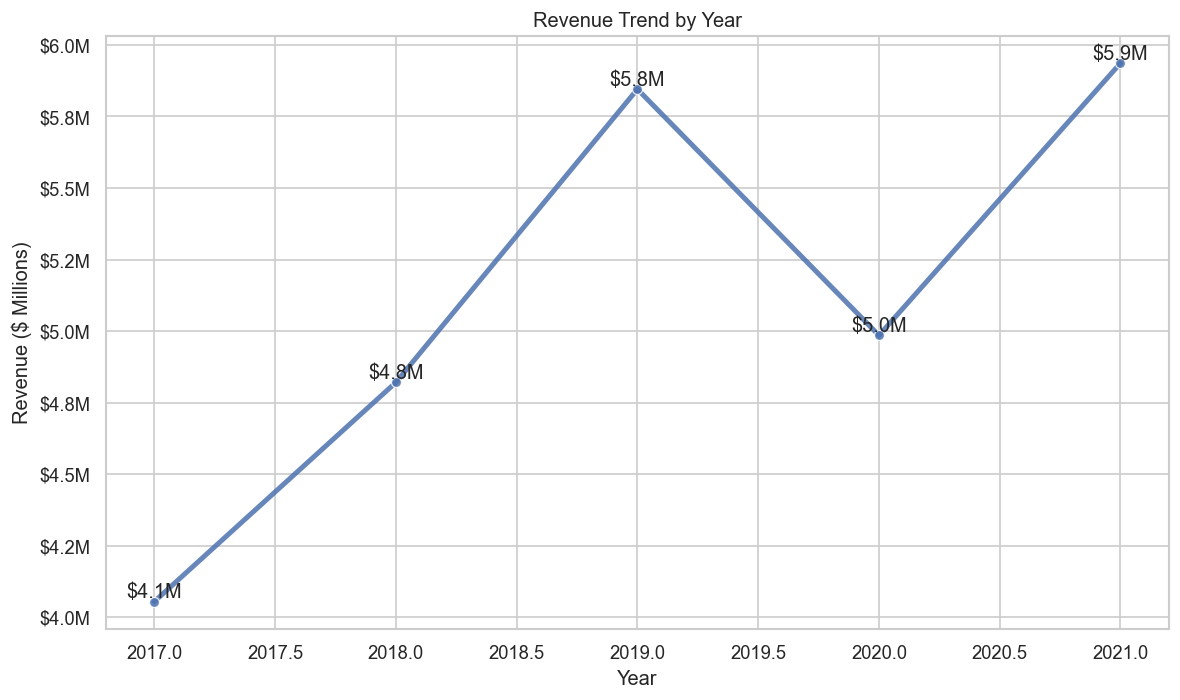

In [7]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_kpis,
    x="order_year",
    y="total_revenue",
    marker="o",
    linewidth=3,
    alpha=0.85,
    color=sns.color_palette("deep")[0]
)

plt.title("Revenue Trend by Year")
plt.xlabel("Year")
plt.ylabel("Revenue ($ Millions)")

# Format y-axis
ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

# Add data labels
for _, row in yearly_kpis.iterrows():
    plt.text(
        row["order_year"],
        row["total_revenue"],
        f"${row['total_revenue']/1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/revenue_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

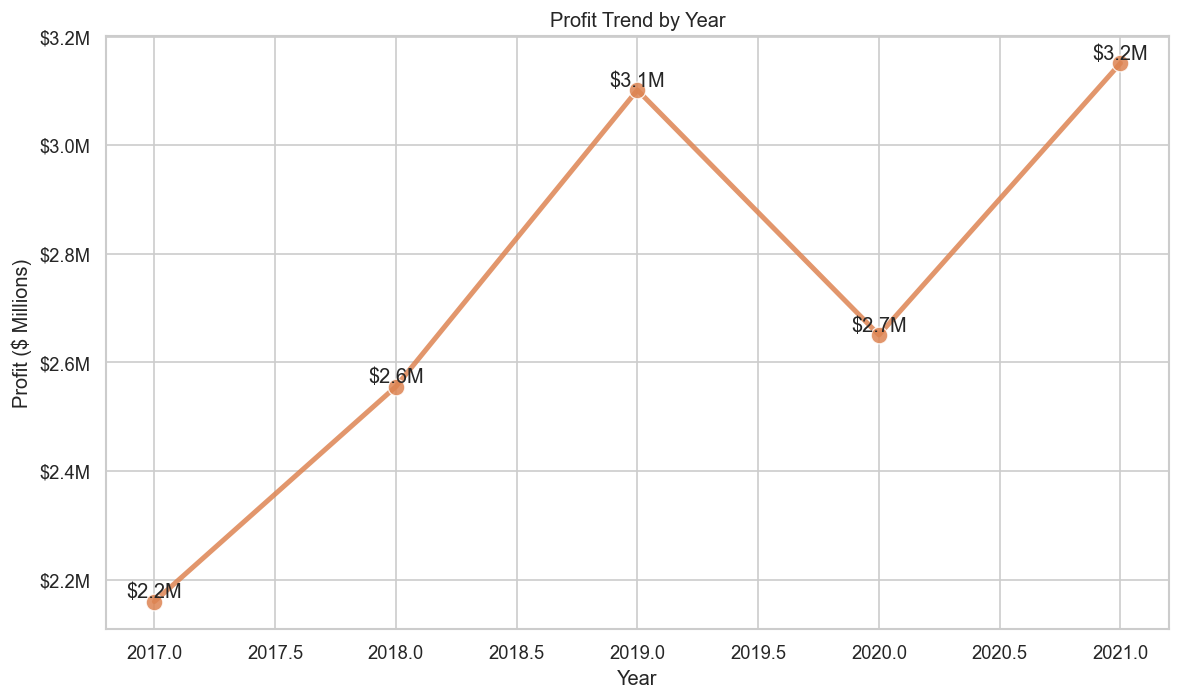

In [8]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_kpis,
    x="order_year",
    y="total_profit",
    marker="o",
    linewidth=3,
    markersize=10,
    alpha=0.85,
    color=sns.color_palette("deep")[1]
)

plt.title("Profit Trend by Year")
plt.xlabel("Year")
plt.ylabel("Profit ($ Millions)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for _, row in yearly_kpis.iterrows():
    plt.text(
        row["order_year"],
        row["total_profit"],
        f"${row['total_profit']/1_000_000:.1f}M",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/profit_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Order Volume Trend

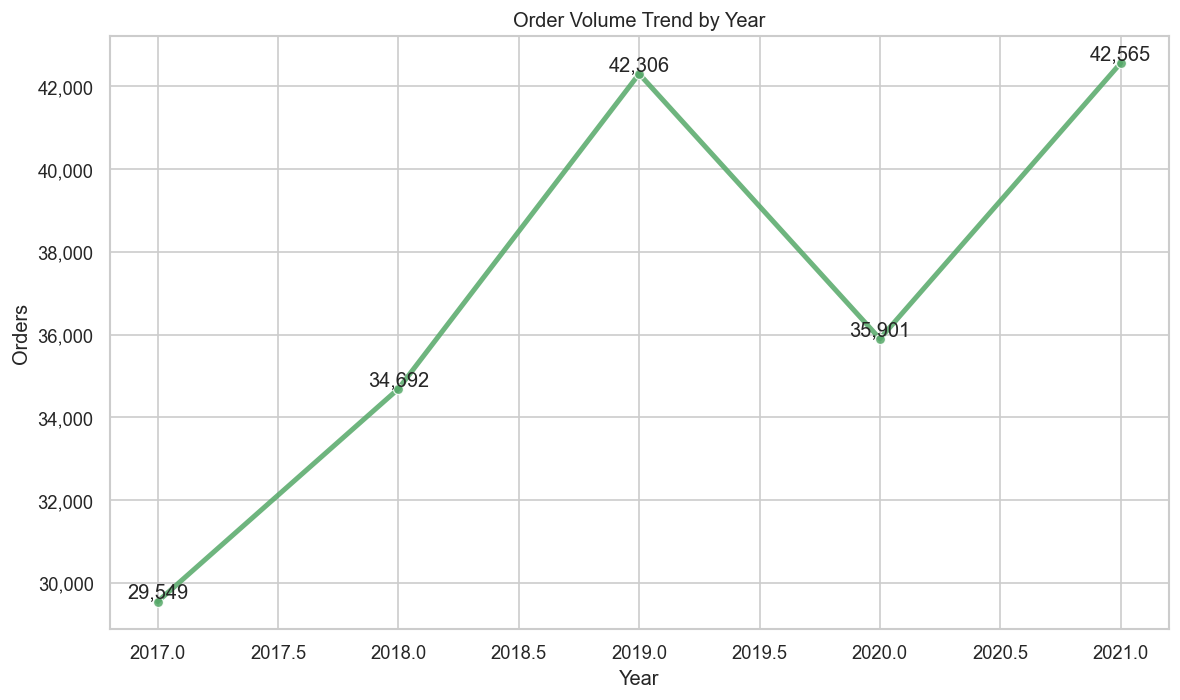

In [9]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_kpis,
    x="order_year",
    y="total_orders",
    marker="o",
    linewidth=3,
    alpha=0.85,
    color=sns.color_palette("deep")[2]
)

plt.title("Order Volume Trend by Year")
plt.xlabel("Year")
plt.ylabel("Orders")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

for _, row in yearly_kpis.iterrows():
    plt.text(
        row["order_year"],
        row["total_orders"],
        f"{int(row['total_orders']):,}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Average Order Value Trend

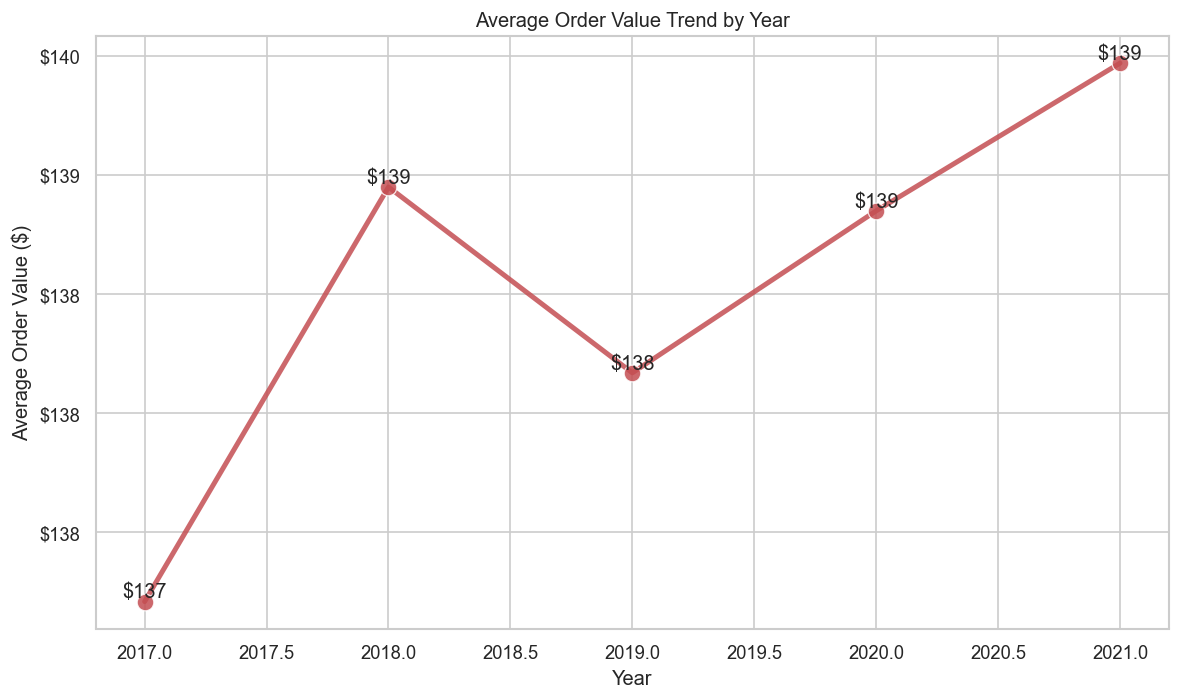

In [10]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

ax = sns.lineplot(
    data=yearly_kpis,
    x="order_year",
    y="average_order_value",
    marker="o",
    linewidth=3,
    markersize=10,
    alpha=0.85,
    color=sns.color_palette("deep")[3]
)

plt.title("Average Order Value Trend by Year")
plt.xlabel("Year")
plt.ylabel("Average Order Value ($)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x:.0f}")
)

for _, row in yearly_kpis.iterrows():
    plt.text(
        row["order_year"],
        row["average_order_value"],
        f"${row['average_order_value']:.0f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/average_order_value_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Executive KPI Findings

Key observations:

- Revenue increased from approximately $4.1M in 2017 to $5.9M in 2021.
- Profit increased from approximately $2.2M in 2017 to $3.2M in 2021.
- Order volume increased from 29,549 orders to 42,565 orders.
- All major KPIs experienced a temporary decline in 2020 before recovering in 2021.
- Average order value remained stable between approximately $137 and $139 throughout the analysis period.

Business Insight:

Revenue growth appears to be driven primarily by increasing order volume rather than higher spending per transaction. The business demonstrates consistent customer purchasing behavior while successfully expanding transaction volume over time.

# 6. Customer Analysis

### Revenue by Customer Segment

In [11]:
display(customer_segments)

,customer_status,total_revenue,total_profit,total_orders,average_order_value
0,Silver,"12,884,922.29","6,845,616.60",92541,139.23
1,Gold,"12,172,776.44","6,462,353.74",88278,137.89
2,Platinum,"583,806.72","310,443.79",4194,139.20


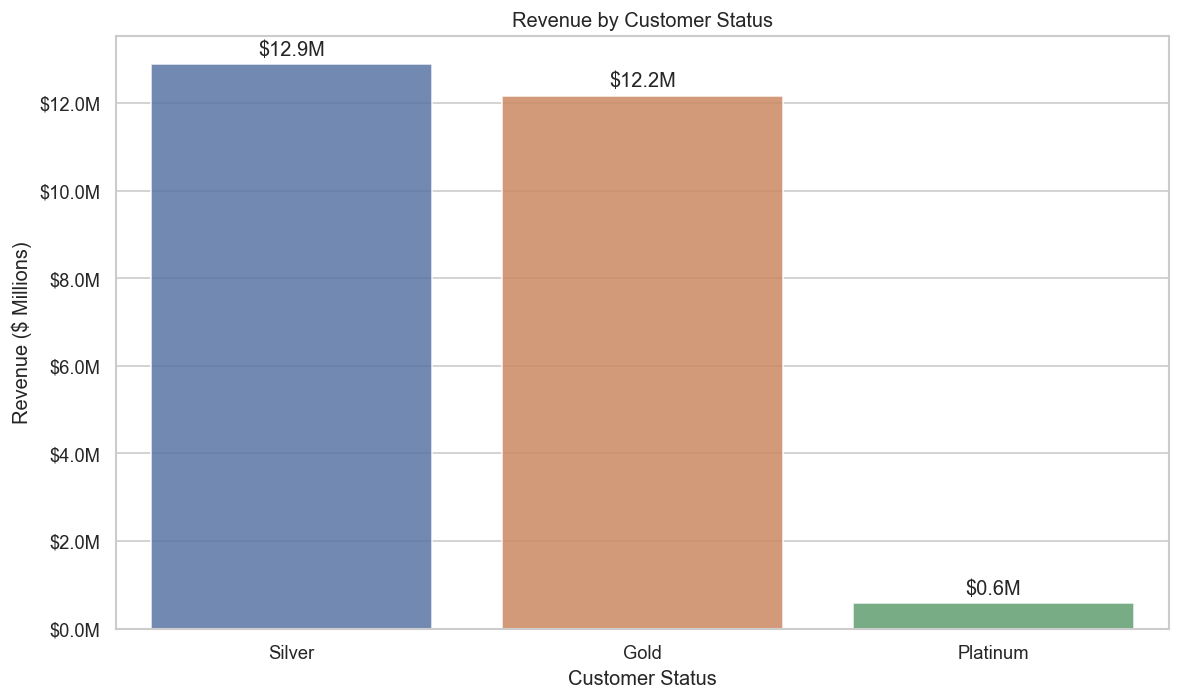

In [12]:
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segments,
    x="customer_status",
    y="total_revenue",
    hue="customer_status",
    palette="deep",
    alpha=0.85,
    legend=False
)

plt.title("Revenue by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Revenue ($ Millions)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"${x/1_000_000:.1f}M",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/revenue_by_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Profit by Customer Status

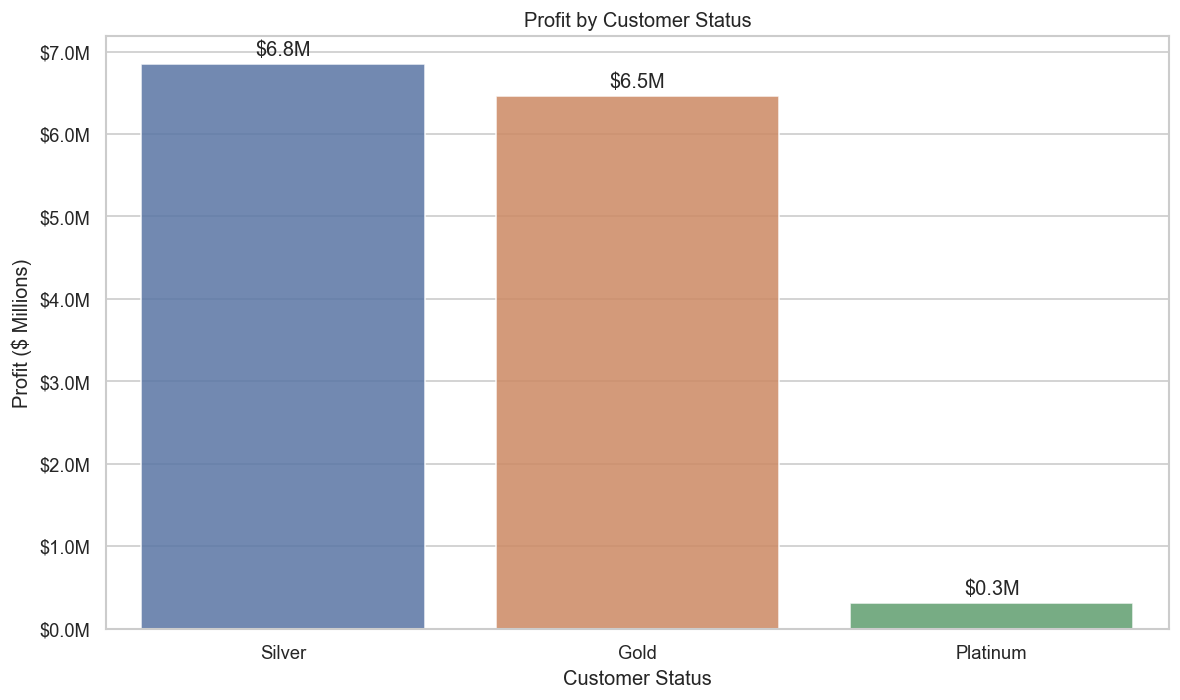

In [13]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segments,
    x="customer_status",
    y="total_profit",
    hue="customer_status",
    palette="deep",
    alpha=0.85,
    legend=False
)

plt.title("Profit by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Profit ($ Millions)")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"${x/1_000_000:.1f}M",
        padding=3
    )

plt.tight_layout()
plt.show()

### Order Volume by Customer Status

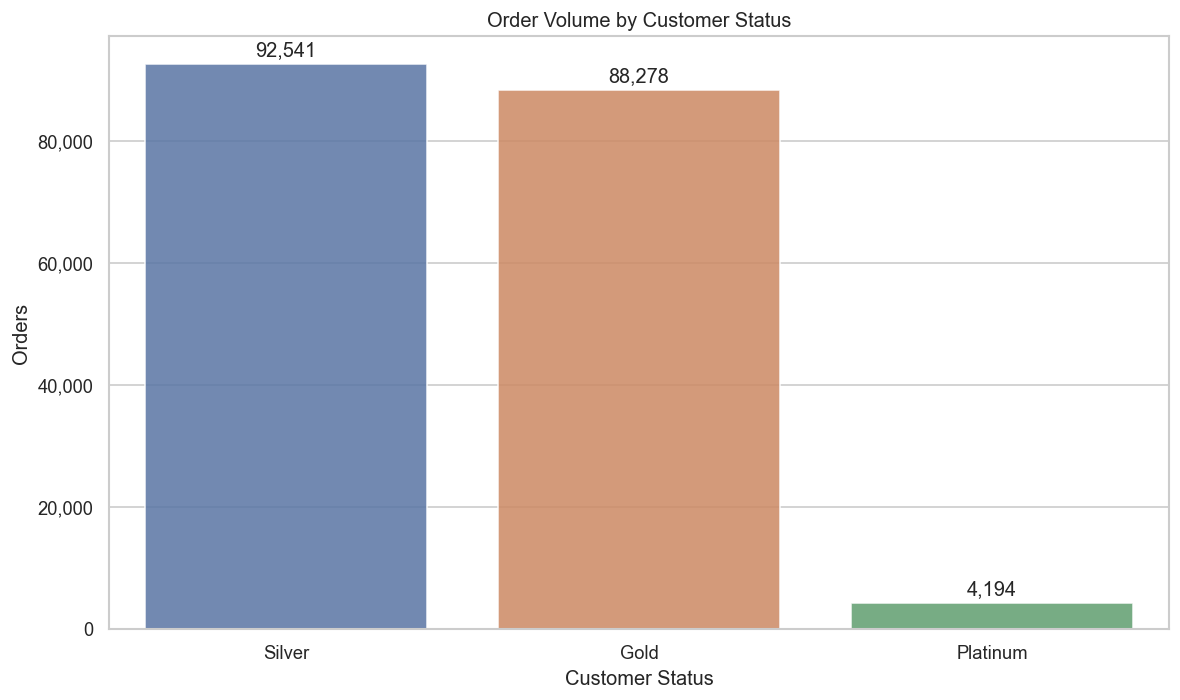

In [14]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=customer_segments,
    x="customer_status",
    y="total_orders",
    hue="customer_status",
    palette="deep",
    alpha=0.85,
    legend=False
)

plt.title("Order Volume by Customer Status")
plt.xlabel("Customer Status")
plt.ylabel("Orders")

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{int(x):,}")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"{int(x):,}",
        padding=3
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/order_volume_by_status.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Customer Analysis Findings

Key Findings:

- Silver customers generated the highest revenue ($12.9M), profit ($6.8M), and order volume (92,541 orders).
- Gold customers performed nearly as strongly as Silver customers, contributing $12.2M in revenue and 88,278 orders.
- Platinum customers represented a very small portion of overall business activity, generating only $0.6M in revenue and 4,194 orders.

Business Insight:

The customer base is heavily concentrated within the Silver and Gold segments, which together account for the overwhelming majority of revenue, profit, and transaction volume. Future customer retention and marketing initiatives should prioritize these segments, while further investigation may be required to understand the low contribution of Platinum customers.

# 7. Product Analysis

### Revenue by Product Category

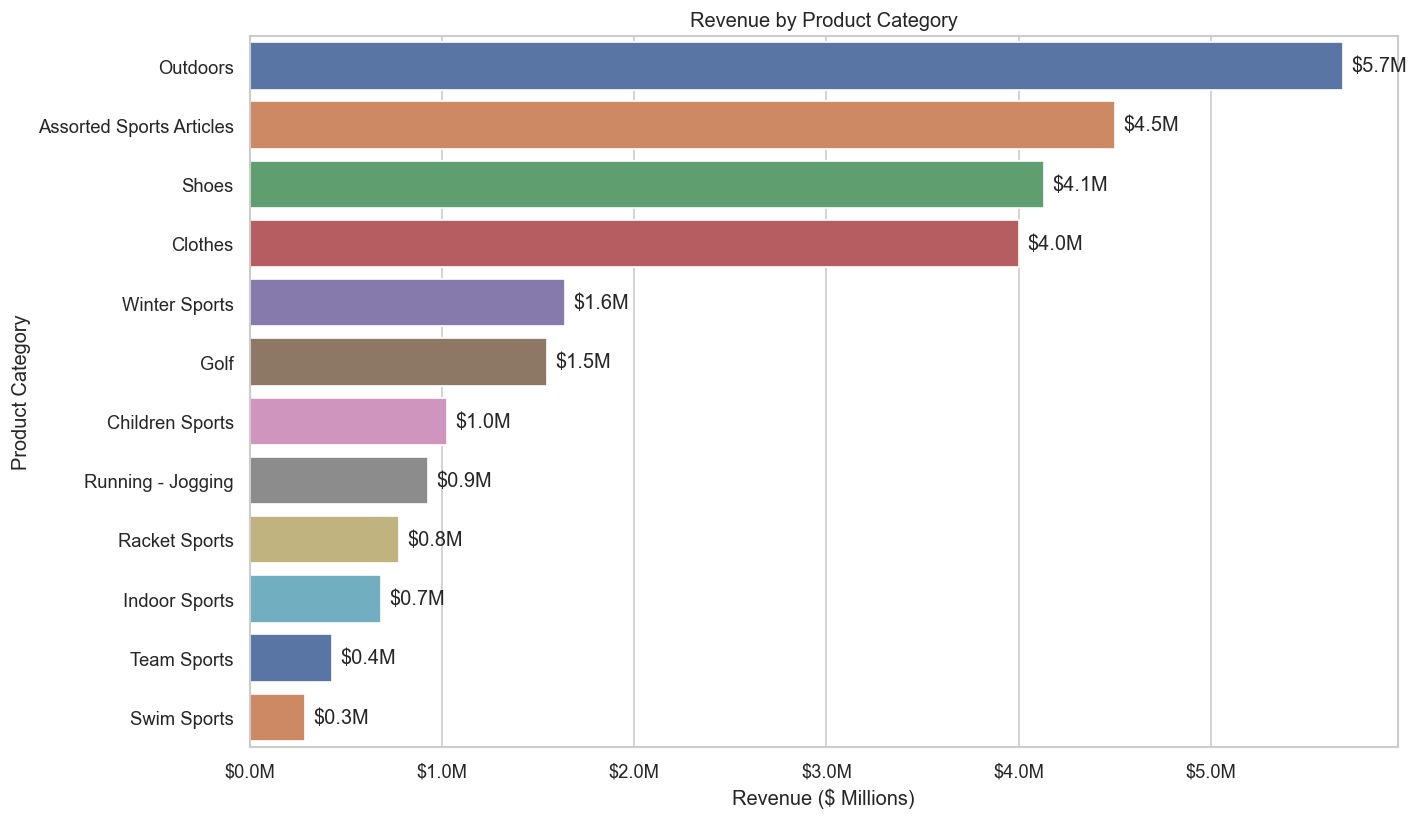

In [15]:
from matplotlib.ticker import FuncFormatter

# Sort highest revenue first
revenue_categories = product_categories.sort_values(
    by="total_revenue",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=revenue_categories,
    x="total_revenue",
    y="product_category",
    hue="product_category",
    palette="deep",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue ($ Millions)")
plt.ylabel("Product Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"${x/1_000_000:.1f}M",
        padding=5
    )

plt.tight_layout()

plt.savefig(
    "../exports/charts/revenue_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- Outdoors generated the highest revenue at approximately $5.7M.
- Assorted Sports Articles ($4.5M), Shoes ($4.1M), and Clothes ($4.0M) formed the second tier of top-performing categories.
- Revenue is concentrated among a small number of categories, with the top four categories contributing the majority of sales.
- Swim Sports and Team Sports generated the lowest revenue, suggesting limited customer demand relative to other product lines.

#### Business Insight

The company should prioritize inventory planning, marketing investment, and supplier relationships for Outdoors, Assorted Sports Articles, Shoes, and Clothes, as these categories drive the largest share of revenue. Lower-performing categories may require targeted promotions, product assortment reviews, or strategic evaluation to improve performance.

### Profit by Product Category

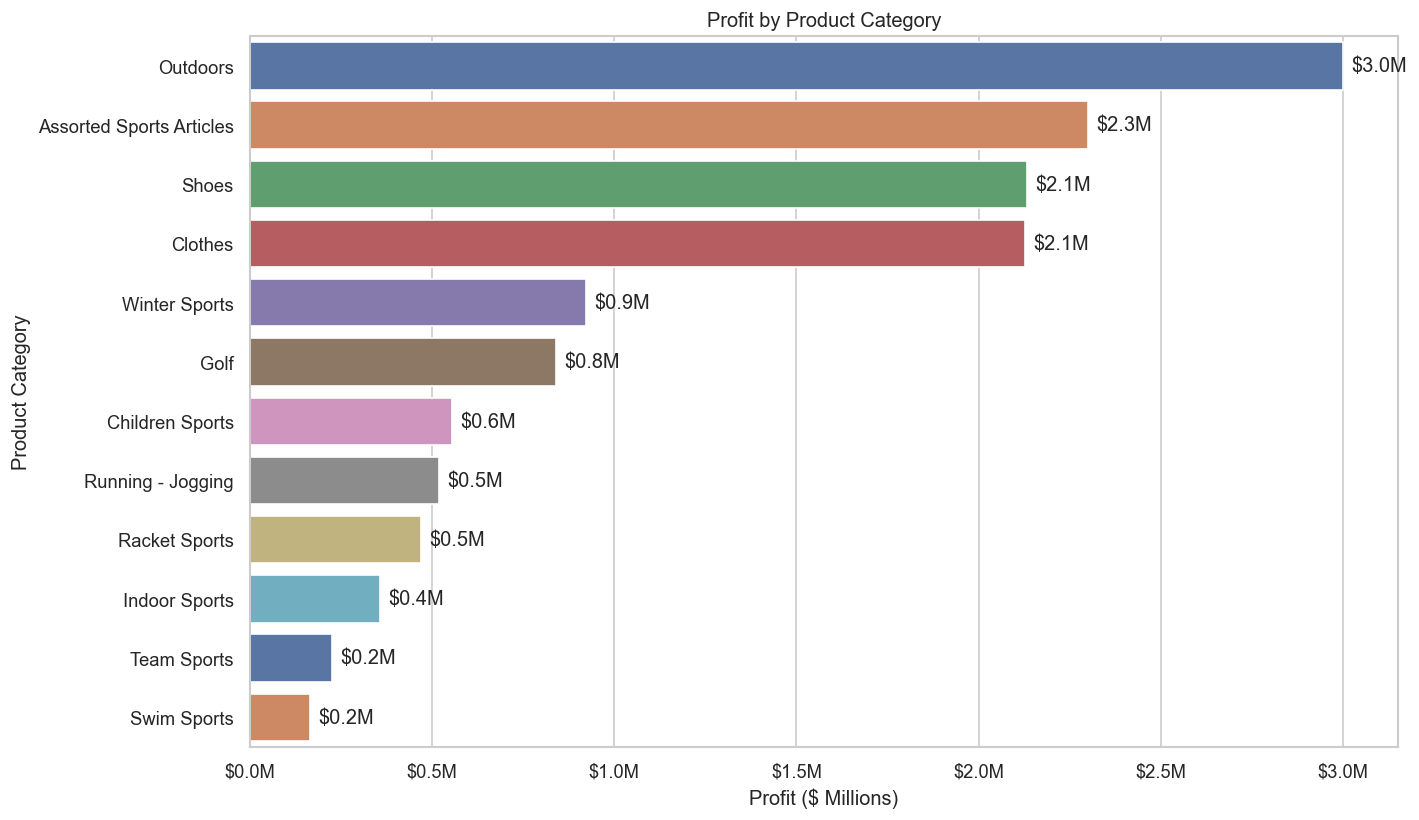

In [16]:
from matplotlib.ticker import FuncFormatter

# Sort highest profit first
product_profit = product_categories.sort_values(
    by="total_profit",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=product_profit,
    x="total_profit",
    y="product_category",
    hue="product_category",
    palette="deep",
    legend=False
)

plt.title("Profit by Product Category")
plt.xlabel("Profit ($ Millions)")
plt.ylabel("Product Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt=lambda x: f"${x/1_000_000:.1f}M",
        padding=5
)

plt.tight_layout()
plt.show()

#### Key Findings

- Outdoors generated the highest revenue at approximately $5.7M.
- Assorted Sports Articles ($4.5M), Shoes ($4.1M), and Clothes ($4.0M) were also major revenue contributors.
- Revenue is concentrated among a small number of product categories, with the top four categories accounting for a substantial share of total sales.
- Swim Sports ($0.3M) and Team Sports ($0.4M) generated the lowest revenue across all categories.

#### Business Insight

Outdoor and sports-related product categories are the primary revenue drivers for the business. Inventory planning, supplier management, and marketing efforts should prioritize these high-performing categories. Lower-performing categories may require targeted promotions, assortment optimization, or strategic review to improve their contribution to overall sales performance.

### Revenue vs Profit by Product Category

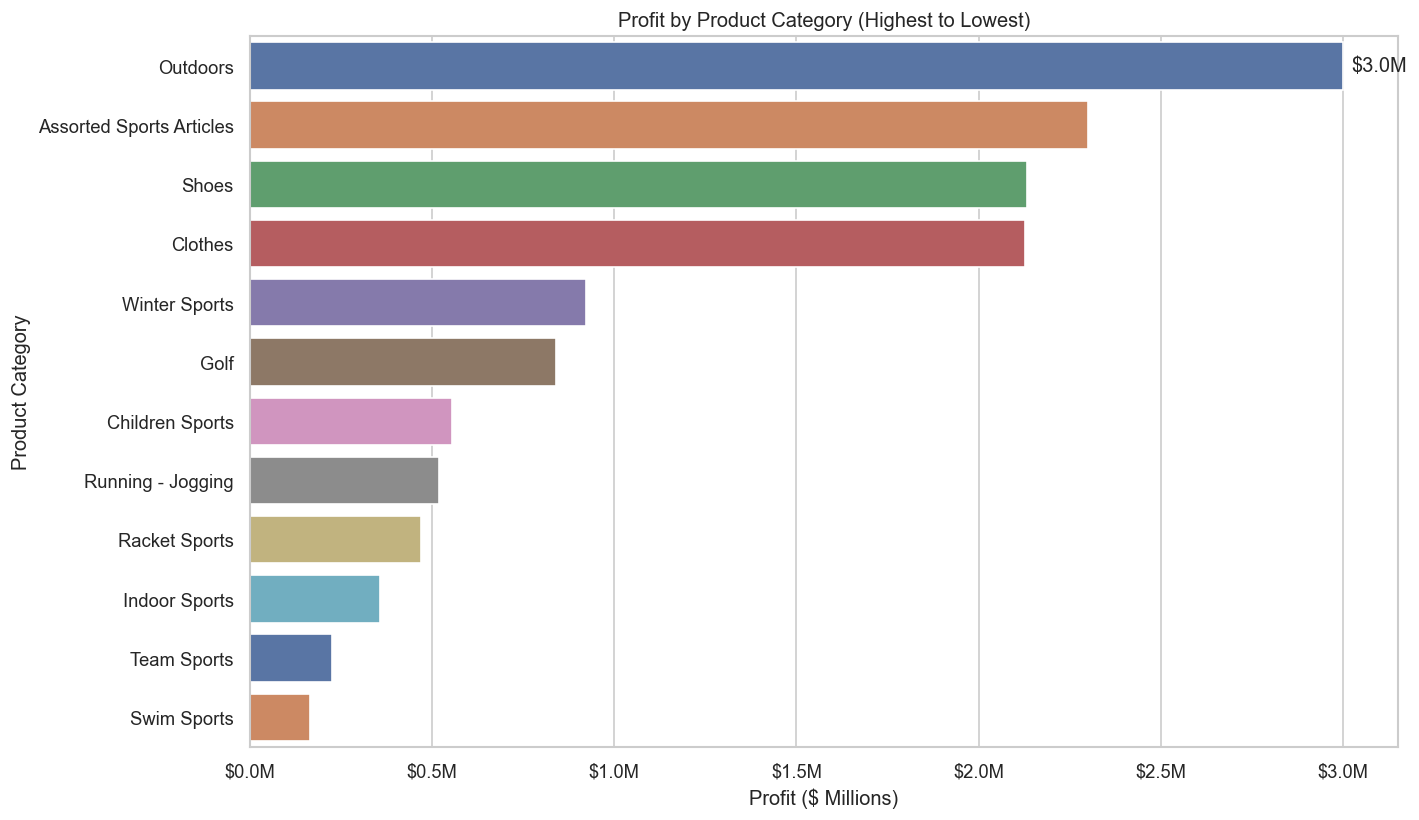

In [17]:
from matplotlib.ticker import FuncFormatter

# Sort by profit descending
product_profit = product_categories.sort_values(
    by="total_profit",
    ascending=False
)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=product_profit,
    x="total_profit",
    y="product_category",
    hue="product_category",
    palette="deep",
    legend=False
)

plt.title("Profit by Product Category (Highest to Lowest)")
plt.xlabel("Profit ($ Millions)")
plt.ylabel("Product Category")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"${x/1_000_000:.1f}M",
    padding=5
)

plt.tight_layout()

plt.savefig(
    "../exports/charts/profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- Outdoors generated the highest profit at approximately $3.0M.
- Assorted Sports Articles ($2.3M), Shoes ($2.1M), and Clothes ($2.1M) were the next most profitable categories.
- Profit performance closely mirrors revenue performance, indicating that the highest-selling categories also generate the greatest profitability.
- Swim Sports ($0.2M) and Team Sports ($0.2M) contributed the least profit across all product categories.

#### Business Insight

Profit rankings closely mirror revenue rankings, indicating that the company's highest-selling product categories are also its most profitable. This suggests strong product-market fit and healthy margins within the business's core product categories.

# 8. Supplier Analysis

### Revenue by Supplier

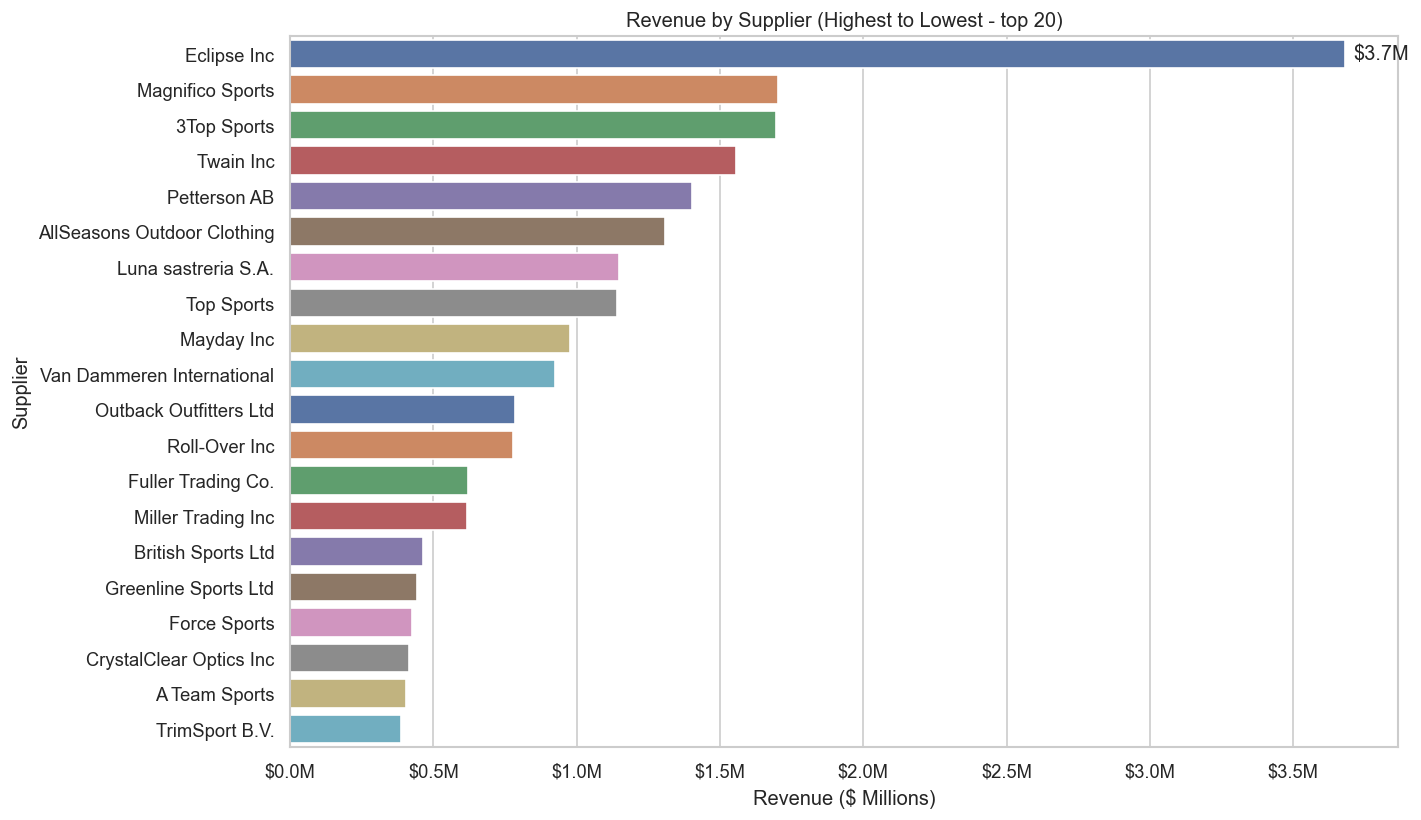

In [18]:
from matplotlib.ticker import FuncFormatter

supplier_revenue_chart = supplier_revenue.sort_values(
    by="total_revenue",
    ascending=False
).head(20)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=supplier_revenue_chart,
    x="total_revenue",
    y="supplier_name",
    hue="supplier_name",
    palette="deep",
    legend=False
)

plt.title("Revenue by Supplier (Highest to Lowest - top 20)")
plt.xlabel("Revenue ($ Millions)")
plt.ylabel("Supplier")

# Format x-axis as millions
ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

# Add value labels to bars
ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"${x/1_000_000:.1f}M",
    padding=5
)

plt.tight_layout()

plt.savefig(
    "../exports/charts/revenue_by_supplier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- Eclipse Inc generated the highest revenue at approximately $3.7M.
- Magnifico Sports ($1.7M), 3Top Sports ($1.7M), and Twain Inc ($1.6M) were the next largest revenue contributors.
- Revenue is concentrated among a relatively small number of suppliers, with Eclipse Inc significantly outperforming the rest.
- The top suppliers collectively account for a substantial share of overall company revenue.

#### Business Insight

Supplier performance is highly concentrated, indicating that a small number of suppliers are critical to revenue generation. Maintaining strong relationships with Eclipse Inc, Magnifico Sports, 3Top Sports, and Twain Inc should be a strategic priority. The business should focus on supplier performance monitoring, contract management, and inventory planning to reduce supply chain risk and support continued revenue growth.

### Profit by Supplier

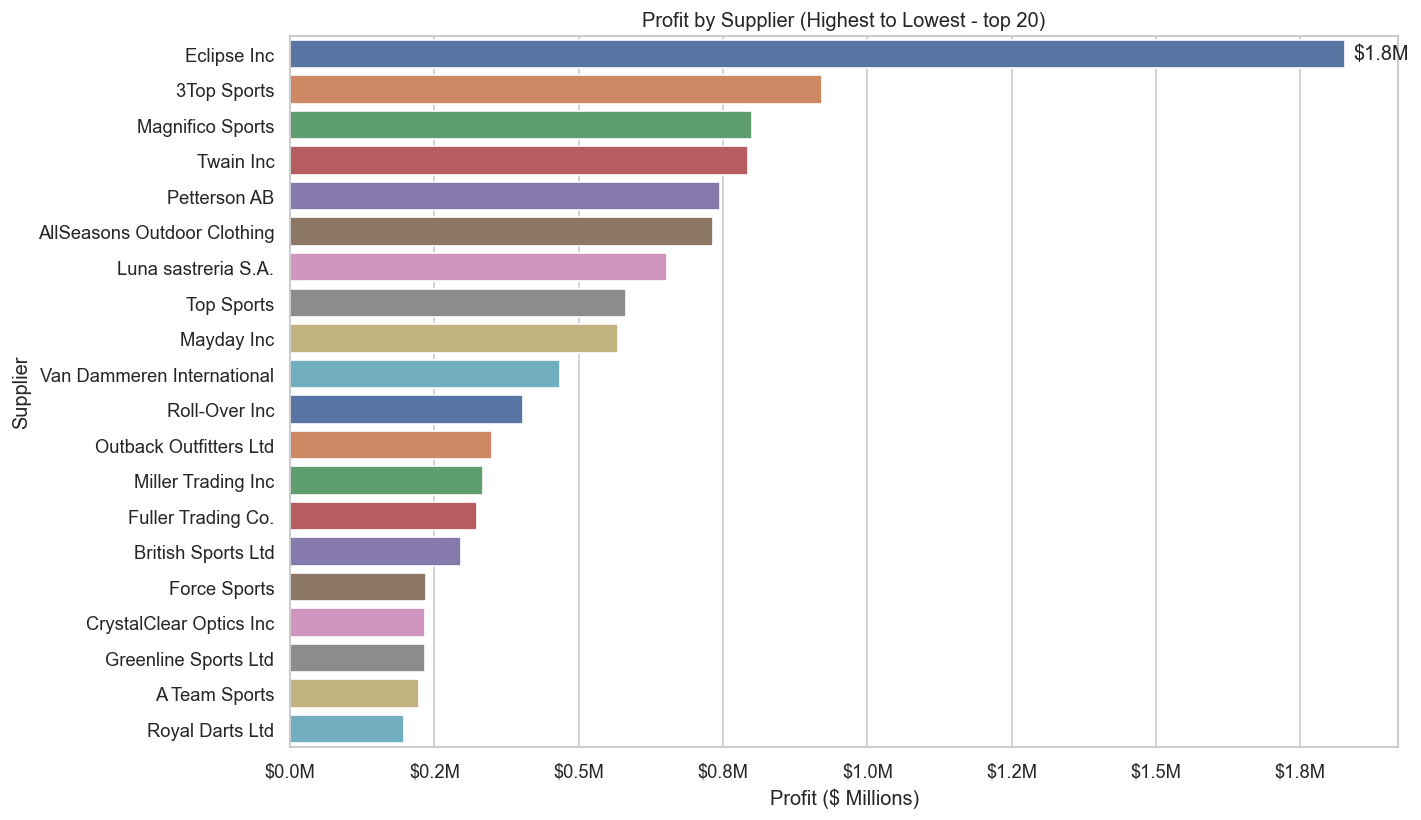

In [19]:
from matplotlib.ticker import FuncFormatter

# Top 10 suppliers by profit
supplier_profit_chart = supplier_profit.sort_values(
    by="total_profit",
    ascending=False
).head(20)

plt.figure(figsize=(12, 7))

ax = sns.barplot(
    data=supplier_profit_chart,
    x="total_profit",
    y="supplier_name",
    hue="supplier_name",
    palette="deep",
    legend=False
)

plt.title("Profit by Supplier (Highest to Lowest - top 20)")
plt.xlabel("Profit ($ Millions)")
plt.ylabel("Supplier")

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

ax.bar_label(
    ax.containers[0],
    fmt=lambda x: f"${x/1_000_000:.1f}M",
    padding=5
)

plt.tight_layout()

plt.savefig(
    "../exports/charts/profit_by_supplier.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- Eclipse Inc generated the highest profit at approximately $1.8M.
- 3Top Sports ($0.9M), Magnifico Sports ($0.8M), and Twain Inc ($0.8M) were the next most profitable suppliers.
- Profit rankings closely mirror revenue rankings, indicating that the highest-revenue suppliers are also the most profitable.
- A small group of suppliers contributes a disproportionate share of overall profitability.

#### Business Insight

The strong alignment between supplier revenue and profit performance suggests that the company's most important supplier relationships are also its most profitable. Maintaining strategic partnerships with Eclipse Inc, 3Top Sports, Magnifico Sports, and Twain Inc can help support inventory availability, operational efficiency, and long-term profitability. The concentration of profit among a small group of suppliers also highlights the importance of supplier diversification and risk management to reduce potential supply chain disruptions.

# 9. Profitability Analysis

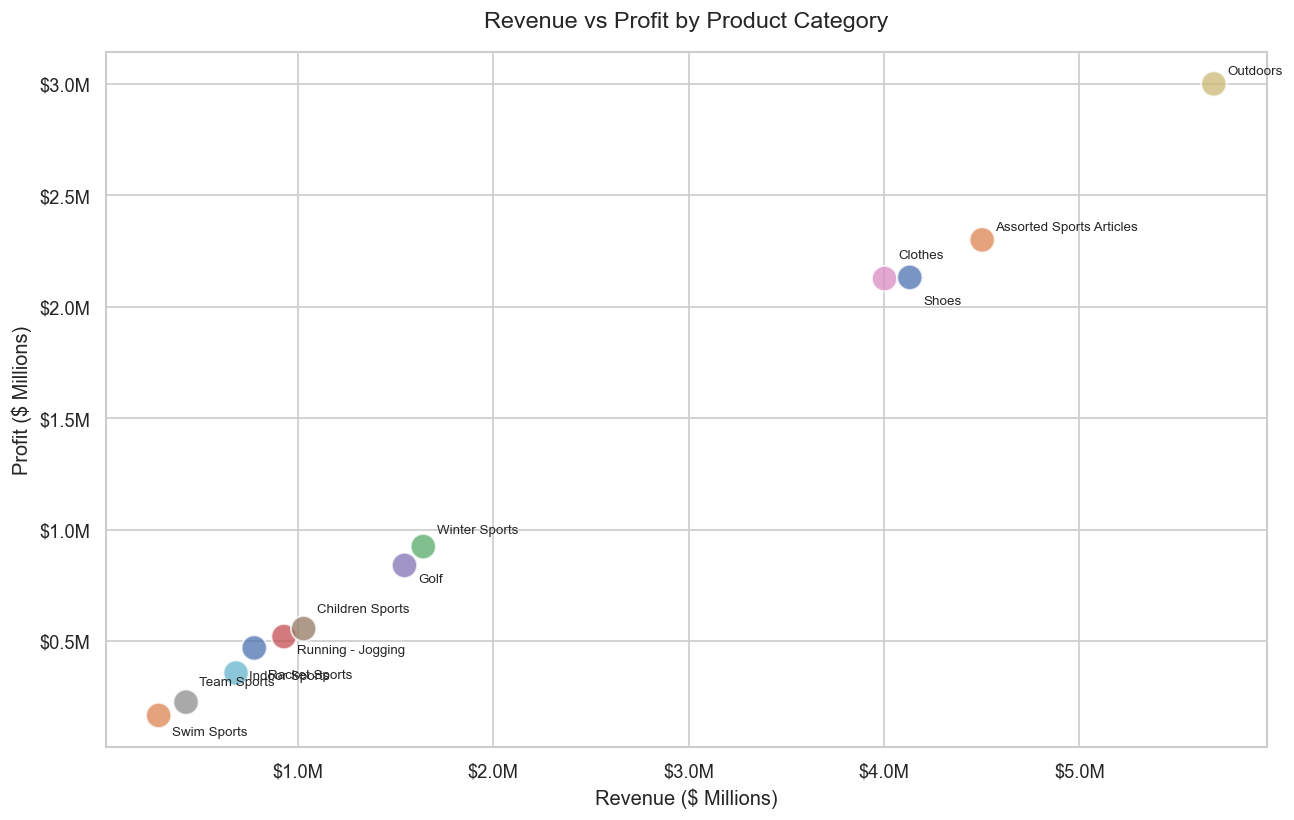

In [20]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

ax = sns.scatterplot(
    data=product_profitability,
    x="total_revenue",
    y="total_profit",
    hue="product_category",
    s=230,
    alpha=0.75,
    palette="deep",
    legend=False
)

# Custom label offsets to reduce overlap
label_offsets = {
    "Outdoors": (8, 6),
    "Assorted Sports Articles": (8, 6),
    "Shoes": (8, -16),
    "Clothes": (8, 12),
    "Winter Sports": (8, 8),
    "Golf": (8, -10),
    "Children Sports": (8, 10),
    "Running - Jogging": (8, -10),
    "Racket Sports": (8, -18),
    "Indoor Sports": (8, -4),
    "Team Sports": (8, 10),
    "Swim Sports": (8, -12),
}

for _, row in product_profitability.iterrows():
    category = row["product_category"]
    offset_x, offset_y = label_offsets.get(category, (6, 6))

    ax.annotate(
        category,
        (row["total_revenue"], row["total_profit"]),
        xytext=(offset_x, offset_y),
        textcoords="offset points",
        fontsize=8
    )

ax.xaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"${x/1_000_000:.1f}M")
)

ax.yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"${y/1_000_000:.1f}M")
)

plt.title("Revenue vs Profit by Product Category", fontsize=14, pad=15)
plt.xlabel("Revenue ($ Millions)")
plt.ylabel("Profit ($ Millions)")

plt.tight_layout()

plt.savefig(
    "../exports/charts/revenue_vs_profit_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- A strong positive relationship exists between revenue and profit across all product categories.
- Outdoors is the highest-performing category, generating both the highest revenue and the highest profit.
- Assorted Sports Articles, Shoes, and Clothes form a second tier of high-performing categories with strong profitability.
- No category appears to generate high revenue while significantly underperforming on profit, indicating generally healthy margins across the product portfolio.

#### Business Insight

The close alignment between revenue and profit suggests that the company's growth is being driven by categories that are both popular and profitable. This reduces the risk of revenue growth being supported by low-margin products. Strategic investment in Outdoors, Assorted Sports Articles, Shoes, and Clothes is likely to deliver the greatest return, while lower-performing categories should be reviewed for pricing, assortment, or promotional optimization opportunities.

# 10. Delivery Analysis

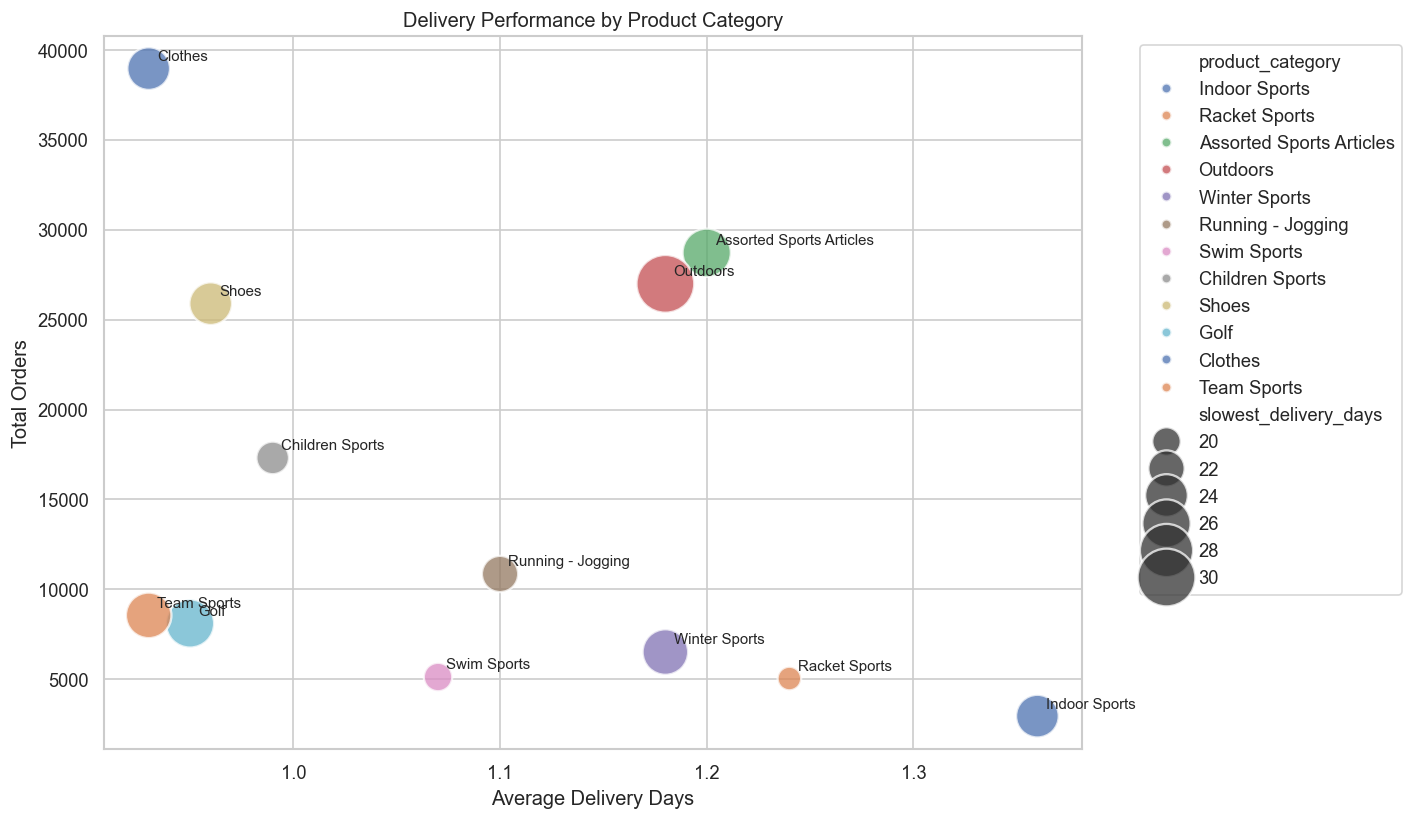

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=delivery_performance,
    x="avg_delivery_days",
    y="total_orders",
    size="slowest_delivery_days",
    hue="product_category",
    sizes=(200, 1200),
    alpha=0.75,
    palette="deep"
)

for _, row in delivery_performance.iterrows():
    plt.annotate(
        row["product_category"],
        (row["avg_delivery_days"], row["total_orders"]),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=9
    )

plt.title("Delivery Performance by Product Category")
plt.xlabel("Average Delivery Days")
plt.ylabel("Total Orders")
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()

plt.savefig(
    "../exports/charts/delivery_performance_by_category.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#### Key Findings

- Average delivery performance is highly consistent across all product categories, ranging from approximately 0.9 to 1.4 days.
- Outdoors and Assorted Sports Articles process some of the highest order volumes while maintaining efficient delivery times.
- Differences in average delivery time are relatively small, suggesting a well-balanced logistics operation across categories.
- Some categories experience longer maximum delivery delays, but these appear to be isolated cases rather than systemic issues.

#### Business Insight

The company's logistics network appears highly efficient and consistent across product categories. High-volume categories continue to achieve fast average delivery times, indicating that operational capacity scales effectively with demand. Maintaining this delivery performance can support customer satisfaction, repeat purchases, and long-term revenue growth while minimizing fulfillment risk.

# 11. Overall Key Findings

### Customer Performance
- Revenue and profit are concentrated among a relatively small number of customer segments.
- Silver and Gold customers contribute the majority of revenue, profitability, and order volume.
- Platinum customers represent a smaller share of overall business activity compared to the leading segments.

### Product Performance
- Outdoors generated the highest revenue and profit across all product categories.
- Assorted Sports Articles, Shoes, and Clothes consistently ranked among the strongest-performing categories.
- Revenue and profitability rankings are closely aligned, indicating healthy margins within the company's top-selling product lines.

### Supplier Performance
- Supplier performance is concentrated among a limited number of vendors.
- Eclipse Inc was the highest contributor to both revenue and profit.
- 3Top Sports, Magnifico Sports, and Twain Inc also played significant roles in overall business performance.
- A small group of suppliers accounts for a substantial share of total revenue and profitability.

### Profitability Insights
- Profit rankings closely mirror revenue rankings across customers, products, and suppliers.
- The business appears to maintain consistent profitability within its highest-performing segments.
- Strong-performing products and suppliers are not only driving sales but also generating healthy profit margins.

### Overall Business Performance
- The business demonstrates strong financial performance driven by a concentrated group of customers, products, and suppliers.
- Revenue generation and profitability are highly aligned across key business dimensions.
- While concentration among top-performing segments supports strong results, it also creates potential operational and business risk if dependence on these segments becomes excessive.

# 12. Strategic Recommendations

### 1. Focus on High-Performing Customer Segments

Prioritize retention, loyalty programs, and targeted marketing campaigns for Silver and Gold customers, as these segments represent the core revenue base of the business.

### 2. Invest in Top Product Categories

Increase inventory availability, marketing support, and promotional efforts for Outdoors, Assorted Sports Articles, Shoes, and Clothes, which consistently generate the highest revenue and profit.

### 3. Strengthen Key Supplier Relationships

Maintain strong partnerships with high-performing suppliers such as Eclipse Inc, 3Top Sports, Magnifico Sports, and Twain Inc to support inventory availability and operational efficiency.

### 4. Review Lower-Performing Categories

Evaluate lower-performing customer segments, product categories, and suppliers to determine whether targeted improvements, pricing adjustments, promotional campaigns, or assortment optimization could improve performance.

### 5. Reduce Concentration Risk

Because revenue and profit are concentrated among a limited number of customers, products, and suppliers, the business should consider diversification strategies to reduce operational and supply chain risk.

# 13. Limitations

- The analysis is based solely on historical transactional data and may not fully predict future business performance.

- Customer demographic information, marketing campaign data, and customer acquisition costs were not available, limiting deeper customer behavior analysis.

- Product profitability was evaluated using available revenue and profit metrics; additional operational costs such as warehousing, logistics, and inventory holding costs were not included.

- Supplier performance was measured primarily through revenue and profitability contribution and does not account for factors such as delivery reliability, product quality, contract terms, or supplier risk.

- External factors such as market conditions, competitor actions, economic trends, and seasonality were outside the scope of this analysis.

- The findings assume the underlying data warehouse and source data are accurate, complete, and representative of actual business operations.

- The analysis focuses on aggregated business performance and may not capture detailed patterns at the individual customer, product, or order level.

# 14. Conclusion

This project leveraged a dimensional data warehouse built in MySQL and Python-based analytics to evaluate retail business performance across customers, products, suppliers, profitability, and operational metrics.

The analysis revealed that revenue and profit are concentrated among a relatively small number of customer segments, product categories, and suppliers. Silver and Gold customers generated the majority of business activity, while product categories such as Outdoors, Assorted Sports Articles, Shoes, and Clothes consistently delivered the strongest financial performance. Supplier analysis further showed that a limited group of vendors, led by Eclipse Inc, contributed a substantial share of overall revenue and profitability.

Profitability patterns closely mirrored revenue performance across all major business dimensions, indicating that the company's highest-performing segments are also its most profitable. While this concentration supports strong financial results, it also highlights potential business and operational risks associated with dependence on a limited number of customers, products, and suppliers.

Overall, the findings demonstrate the value of combining dimensional modeling, SQL analytics, and data visualization to support business decision-making. By continuing to invest in high-performing segments while reducing concentration risk and improving lower-performing areas, the business can strengthen long-term resilience, profitability, and sustainable growth.